<a href="https://colab.research.google.com/github/donjadao/lis4693_don_jacky_final_project/blob/main/data/lis4693_don_jacky_final_project/data/Copy_of_Topic_Modeling_Descriptive_Analysis_Network_Analysis_Altair_Visualization_of_Ramen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Ramen
Final Project for Text Mining
Don Dao, Jacky Chen


importing libraries and vader_lexicon for sentiment analysis

In [13]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Loading data from github repo on amazon ramen reviews

In [14]:
url = "https://raw.githubusercontent.com/donjadao/lis4693_don_jacky_final_project/main/data/ramen_reviews_long.csv"
df = pd.read_csv(url)

df.head()

,ProductId,Score,Summary,Text,Time,HelpfulnessNumerator,HelpfulnessDenominator
0,B003OB0IB8,4,Tastes great. Love Hot & Spicy. Bad price here.,I've been a fan of Hot & Spicy Maruchan Ramen ...,1325808000,4,4
1,B003OB0IB8,5,My favorite ramen,I've been eating Ramen noodles since I was a l...,1314489600,4,4
2,B003OB0IB8,3,It burns!,"I LOVE spicy ramen, but for whatever reasons t...",1329436800,3,3
3,B003OB0IB8,5,Amazing to the last bite.,Always being a fan of ramen as a quick and eas...,1330473600,1,1
4,B003OB0IB8,4,"Tastes great, but is cheaper locally.",I love this flavor of ramen! I don't eat other...,1333756800,0,0


In [15]:
df["ProductId"].nunique()

545

# Question 1 What is the 'text' field for your dataset?

The text field in my dataset are the review of each ramen

Here I am just labeling each review as positive, negative, and neutral based on the amazon rating it recieved, this has nothing to do with the text of the review itself.

In [16]:
def rating_to_label(score):
    if score >= 4:
        return "pos"
    elif score <= 2:
        return "neg"
    else:
        return "neutral"

df["label"] = df["Score"].apply(rating_to_label)
df = df.dropna(subset=["label"])

In [17]:

analysis_df = df.rename(columns={
    "Text": "review_text"
})[["review_text", "label"]].reset_index(drop=True)

analysis_df["review_id"] = analysis_df.index

analysis_df = analysis_df[["review_id", "review_text", "label"]]
analysis_df.head()


,review_id,review_text,label
0,0,I've been a fan of Hot & Spicy Maruchan Ramen ...,pos
1,1,I've been eating Ramen noodles since I was a l...,pos
2,2,"I LOVE spicy ramen, but for whatever reasons t...",neutral
3,3,Always being a fan of ramen as a quick and eas...,pos
4,4,I love this flavor of ramen! I don't eat other...,pos


# Preprocessing textual data
Create new dataframe with "id" and "text" field.

In [18]:
analysis_df = pd.DataFrame({
    "review_id": range(len(df)),
    "review_text": df["Text"],
    "label": df["label"]
})

Remove all non-alphabet characters

In [19]:
analysis_df['review_text'] = analysis_df['review_text'].str.replace(
    "[^a-zA-Z#]", " ", regex=True
)

convert to lowercase

In [20]:
analysis_df['review_text'] = analysis_df['review_text'].str.casefold()
print(analysis_df.head(10))

   review_id                                        review_text    label
0          0  i ve been a fan of hot   spicy maruchan ramen ...      pos
1          1  i ve been eating ramen noodles since i was a l...      pos
2          2  i love spicy ramen  but for whatever reasons t...  neutral
3          3  always being a fan of ramen as a quick and eas...      pos
4          4  i love this flavor of ramen  i don t eat other...      pos
5          5  i started my cat on felidae platinum about   w...      pos
6          6  these are my favorite  but they aren t for eve...      pos
7          7  excellent in cereal  or on top icecream sundae...      pos
8          8  i m not so sure why the other guy didn t like ...      pos
9          9  this is ramen  a cheap  easy  and fast noodle ...  neutral


# Generate Sentiment Polarity Scores

create a dataframe for staging the output of the SentimentIntensityAnalyzer.polarity_scores method.

instantiating an object of the class SentimentIntensityAnalyzer and running a for-loop to iterate the polarity_scores method over each row of input text dataframe df_subset. Another for loop is embedded with the earlier loop to write the sentiment polarity score for each sentiment type to an intermediate dataframe.

Deleting the dummy row from the output dataframe
Removing any duplicate rows that could potentially creep into the output dataframe
Filtering the output dataframe to only keep rows for sentiment type of compound

In [21]:
df_subset = analysis_df.copy()

In [22]:
print("Processing sentiment analysis...")

sid = SentimentIntensityAnalyzer()

all_scores_list = []

for _, row in df_subset.iterrows():
    scores = sid.polarity_scores(row["review_text"])
    all_scores_list.append({
        "review_id": row["review_id"],
        "review_text": row["review_text"],
        "compound": scores["compound"],
        "pos": scores["pos"],
        "neu": scores["neu"],
        "neg": scores["neg"]
    })

sentiment_df = pd.DataFrame(all_scores_list)

sentiment_df.head()

Processing sentiment analysis...


,review_id,review_text,compound,pos,neu,neg
0,0,i ve been a fan of hot spicy maruchan ramen ...,0.9022,0.305,0.626,0.068
1,1,i ve been eating ramen noodles since i was a l...,0.7812,0.218,0.739,0.043
2,2,i love spicy ramen but for whatever reasons t...,0.5936,0.208,0.672,0.120
3,3,always being a fan of ramen as a quick and eas...,0.8658,0.245,0.755,0.000
4,4,i love this flavor of ramen i don t eat other...,0.1280,0.055,0.898,0.048


## Advanced Text Cleaning for BERTopic

To improve topic quality, we will apply additional cleaning steps, including tokenization, lemmatization, and more comprehensive stop word removal. This helps the topic model focus on more meaningful words.

In [23]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words_nltk = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_for_bertopic(text):
    text = str(text).lower() # Ensure text is string and lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    tokens = text.split()
    # Combine NLTK stopwords with custom ramen-related stopwords, including new pet-related terms
    custom_stops = {'ramen', 'noodle', 'noodles', 'flavor', 'flavour', 'instant', 'style', 'like', 'just', 'get', 'dont', 'got', 'br', 'com', 'amazon', 'dog', 'cat', 'food', 'pet', 'pound'}
    all_stops = stop_words_nltk.union(custom_stops)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in all_stops and len(w) > 2] # Remove stopwords and short words
    return " ".join(tokens)

# Initialize bertopic_df from an existing DataFrame that contains 'review_text'
bertopic_df = analysis_df.copy()

# Apply this advanced cleaning to the review_text column
bertopic_df['cleaned_review_text'] = bertopic_df['review_text'].apply(clean_text_for_bertopic)

print(bertopic_df[['review_text', 'cleaned_review_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                         review_text  \
0  i ve been a fan of hot   spicy maruchan ramen ...   
1  i ve been eating ramen noodles since i was a l...   
2  i love spicy ramen  but for whatever reasons t...   
3  always being a fan of ramen as a quick and eas...   
4  i love this flavor of ramen  i don t eat other...   

                                 cleaned_review_text  
0  fan hot spicy maruchan long time enjoy spice l...  
1  eating since little kid never found better hot...  
2  love spicy whatever reason thing burn stomach ...  
3  always fan quick easy meal finding decent pric...  
4  love eat flavor anymore taste bland comparison...  


Simplifying the output dataframe to just the score and text

In [24]:
sentiment_df.sample(3)[["compound", "review_text"]]

,compound,review_text
758,0.9125,beg to differ with previous reviewer i really...
796,0.9682,and healthier than ramen noodles i took a cha...
414,0.9966,i am gluten intolerant but have not taken to ...


In [25]:
all_scores_list.append({
    "review_id": row["review_id"],
    "compound": scores["compound"],
    "pos": scores["pos"],
    "neu": scores["neu"],
    "neg": scores["neg"]
})

In [26]:
sentiment_df.columns

Index(['review_id', 'review_text', 'compound', 'pos', 'neu', 'neg'], dtype='object')

# Visualize Sentiment Analysis Output

generates summary statistics of sentiment_score field of df_output dataframe.

In [27]:
sentiment_df[["compound"]].describe()

,compound
count,1241.000000
mean,0.745197
std,0.402816
min,-0.969800
25%,0.738400
50%,0.906200
75%,0.967400
max,0.999100


# Briefly explain your sentiment polarity results using the `describe` method.

The sentiment polarity results from the `describe` method shows us that the mean sentiment is about 0.745 which means the majority of sentiment is extremely positive. The median value being 0.906 means that more than 90% of the data also show strong positivity. The max and minimun scores are both near |0.99| (absolute value) which means there are some pretty passionate reviews on both ends. I wonder what those reviews look like so lets put it below. The std is 0.40 so that means there is a small amount of difference in reviews. Most of the reviews are clustered in the positive range.

In [28]:

most_positive = sentiment_df.loc[
    sentiment_df['compound'].idxmax(),
    ['compound', 'review_text', 'review_id']
]

print(most_positive['review_text'])

when i run out of these  i don t buy whatever more conveniently available brand happens to be a   minute drive away   no other instant noodles product compares to this    i ll wait however long it takes to stock up again with this specific product    regardless of how relatively inconvenient the access is for me to obtain this from the vendor who has stocked this product for the entire time i ve been purchasing it    enjoying it  br    br   with that being said  i have a definite affinity for the pork flavor of this product  as well    but when i stock up  i purchase both    it doesn t end up being a       split  br    br   the taste of this product is unique    the  spice factor  is such that there is definitely a  kick   when i was a kid  i used to wonder how a close relative of mine could  stand  spicy foods  especially when it made him sweat   sniffle    well  now i  get  it       br    br   it s worth noting that if one wishes to manipulate the spice intensity  making a more dilut

wow this is pretty positive

In [29]:

most_negative = sentiment_df.loc[
    sentiment_df['compound'].idxmin(),
    ['compound', 'review_text', 'review_id']
]

print(most_negative['review_text'])


i ordered this because it s vegetarian and i ve been trying to find a good tomato flavored ramen  i used to buy maruchan but they ve discontinued it   i really should have tried to find it closer to me and tried one bowl of soup before buying a whole case  it tastes awful  it s really bitter and doesn t taste at all like tomato to me  after initially trying it i let it sit for a while so the noodles could absorb the juice more and see if that tempered the bitterness  but they don t  it s unfixable  sorry  br    br   gross gross gross 


In the most negative review, they mentioned vegan. Most people have a vision of vegan food that it doesn't taste as good as their meaty counterparts. I'm going to do an analysis of just the vegan ramen.

In [30]:
vegan_df = sentiment_df[
    sentiment_df["review_text"].str.contains(
        r"\bvegan\b",
        case=False,
        na=False,
        regex=True
    )
]

len(vegan_df)

42

In [31]:
vegan_df["compound"].describe()

,compound
count,42.000000
mean,0.815952
std,0.315601
min,-0.948500
25%,0.675275
50%,0.930850
75%,0.971250
max,0.998800


Vegans have always had fewer options to choose from. Whether or not they are expecting the food to live up to their expectations of what "regular" ramen vs. "vegan" ramen is up to the customer. Some may choose to evaluate products more forgivingly or more harshly. Overall, the results still show that the mean is still positive and the 50% median being 0.93 means there are overweamlinly positive results.

In [32]:
df["label"] = df["Score"].apply(rating_to_label)

In [33]:
sentiment_df = sentiment_df.merge(
    df_subset[["review_id", "label"]],
    on="review_id",
    how="left"
)

In [34]:
mean_by_label = (
    sentiment_df
    .groupby("label")[["compound"]]
    .mean()
)

mean_by_label

,compound
label,
neg,0.278995
neutral,0.663414
pos,0.812264


The fact that the negative mean compound score could be a result of many things. One hypothetical could be that the vadar analysis of the reiviews wrongy identifies negative reviews. Another reason is that customers don't just put negative language in their reviews, it could be a mix of pros and cons.

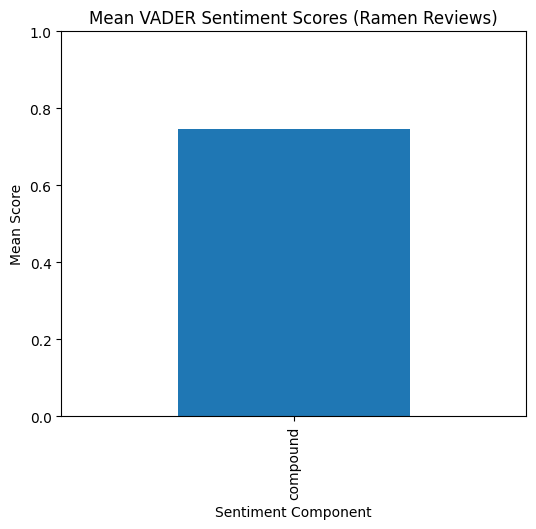

In [35]:
# Compute mean VADER scores
mean_scores = sentiment_df[["compound"]].mean()

# Bar plot
mean_scores.plot(
    kind="bar",
    figsize=(6, 5),
    title="Mean VADER Sentiment Scores (Ramen Reviews)",
    ylabel="Mean Score"
)

plt.ylim(0, 1)
plt.xlabel("Sentiment Component")
plt.show()

In [36]:
import seaborn as sns


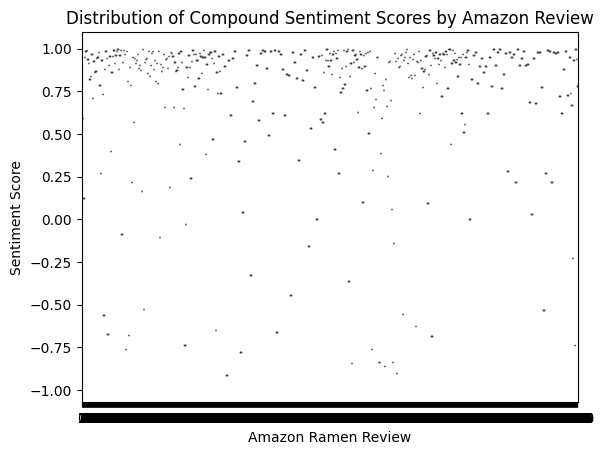

In [37]:
sns.boxplot(
    data=sentiment_df,
    x='review_id',
    y='compound'
)

plt.title('Distribution of Compound Sentiment Scores by Amazon Review')
plt.xlabel('Amazon Ramen Review')
plt.ylabel('Sentiment Score')
plt.show()


Here we can see an obvious skew towards positive reviews

Creating a series of box plots to see the spread of how accurate positive, neutral, and negative results are.

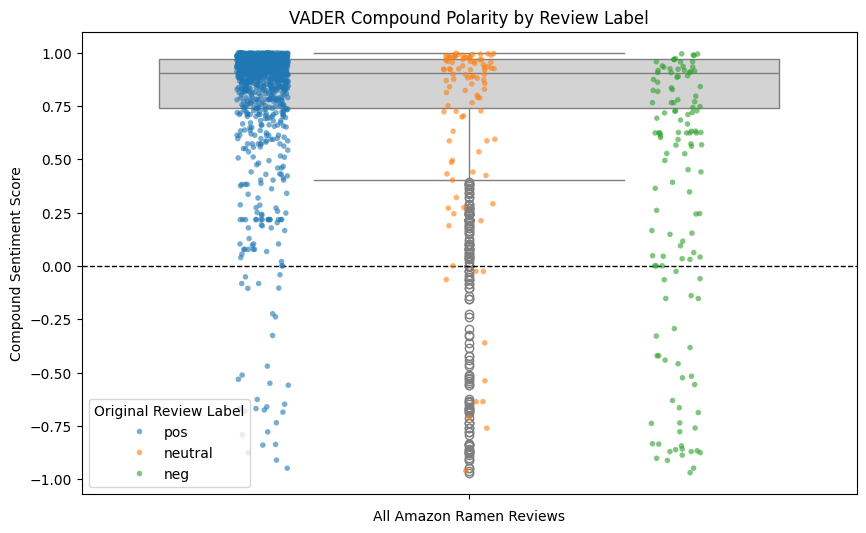

In [38]:
plt.figure(figsize=(10, 6))

# Boxplot for distribution
sns.boxplot(
    data=sentiment_df,
    y="compound",
    color="lightgray"
)

# Overlay individual points
sns.stripplot(
    data=sentiment_df,
    y="compound",
    hue="label",
    dodge=True,
    alpha=0.6,
    size=4,
    jitter=True
)

plt.title("VADER Compound Polarity by Review Label")
plt.ylabel("Compound Sentiment Score")
plt.xlabel("All Amazon Ramen Reviews")
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.legend(title="Original Review Label")
plt.show()


The blue is positive and should primarily reside near 1, negative near -1, and neutral around 0. It seems like neutral review have a harder time of having its language analized. The negative results seem spread out, again since there could be positive and negative tone in the reviews.

In [39]:

mean_scores = (
    sentiment_df[["compound"]]
    .mean()
    .reset_index()
    .rename(columns={"index": "sentiment_component", 0: "mean_score"})
)


In [40]:
import altair as alt

Doing more categories besides vegan

---



In [41]:
flavor_keywords = {
    "pork": r"\bpork\b",
    "beef": r"\bbeef\b",
    "chicken": r"\bchicken\b",
    "shrimp": r"\bshrimp\b",
    "seafood": r"\bseafood\b|\bfish\b",
    "spicy": r"\bspicy\b|\bhot\b|\bchili\b",
    "vegan": r"\bvegan\b",
    "savory_umami": r"\bsavory\b|\bumami\b",
    "creamy_rich": r"\bcreamy\b|\brich\b|\bbroth\b",
    "vegetable_herb": r"\bvegetable\b|\bveg\b|\bherb\b|\bgreen\b",
    "sweet_soy": r"\bsweet\b|\bsoy\b",
    "curry": r"\bcurry\b"
}

seperating the original data into categories

In [42]:
def assign_flavor(text):
    text = text.lower()
    for flavor, pattern in flavor_keywords.items():
        if pd.notna(text) and pd.Series(text).str.contains(pattern, regex=True).any():
            return flavor
    return None

In [43]:
sentiment_df["flavor"] = sentiment_df["review_text"].apply(assign_flavor)
flavor_df = sentiment_df.dropna(subset=["flavor"])

In [44]:
flavor_describe = (
    flavor_df
    .groupby("flavor")["compound"]
    .describe()
)

flavor_describe

,count,mean,std,min,25%,50%,75%,max
flavor,,,,,,,,
beef,87.0,0.685505,0.495053,-0.8617,0.670700,0.92080,0.968400,0.9963
chicken,168.0,0.811517,0.372063,-0.9485,0.859850,0.95255,0.985275,0.9986
creamy_rich,63.0,0.609395,0.423567,-0.8402,0.216900,0.82180,0.952650,0.9962
curry,4.0,0.340075,0.859060,-0.9021,0.097725,0.67315,0.915500,0.9161
pork,38.0,0.916887,0.128803,0.3400,0.904675,0.96825,0.984475,0.9991
savory_umami,9.0,0.923144,0.069093,0.7588,0.907000,0.94770,0.969800,0.9809
seafood,52.0,0.807608,0.385566,-0.9106,0.840400,0.91880,0.981550,0.9963
shrimp,27.0,0.848548,0.336722,-0.7363,0.876650,0.94410,0.971450,0.9964
spicy,287.0,0.814715,0.306595,-0.9604,0.833800,0.92730,0.968650,0.9968


In [45]:
print("Distribution of Ramen Flavors:")
display(flavor_df['flavor'].value_counts())

Distribution of Ramen Flavors:


,count
flavor,
spicy,287
chicken,168
beef,87
creamy_rich,63
seafood,52
pork,38
vegan,27
shrimp,27
sweet_soy,24


In [46]:
alt.Chart(sentiment_df).mark_boxplot(
    extent="min-max"
).encode(
    x=alt.X(
        "flavor:N",
        title="Ramen Flavor / Protein",
        sort="-y"
    ),
    y=alt.Y(
        "compound:Q",
        title="VADER Compound Polarity",
        scale=alt.Scale(domain=[-1, 1])
    ),
    color=alt.Color(
        "flavor:N",
        legend=None
    ),
    tooltip=[
        alt.Tooltip("flavor:N", title="Flavor"),
        alt.Tooltip("compound:Q", title="Compound Polarity", format=".3f")
    ]
).properties(
    width=800,
    height=450,
    title="Distribution of VADER Polarity by Ramen Flavor"
)

alt.Chart(...)

/tmp/ipykernel_5506/822549479.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='flavor', y='Score', data=average_flavor_scores.sort_values(by='Score', ascending=False), palette='viridis')


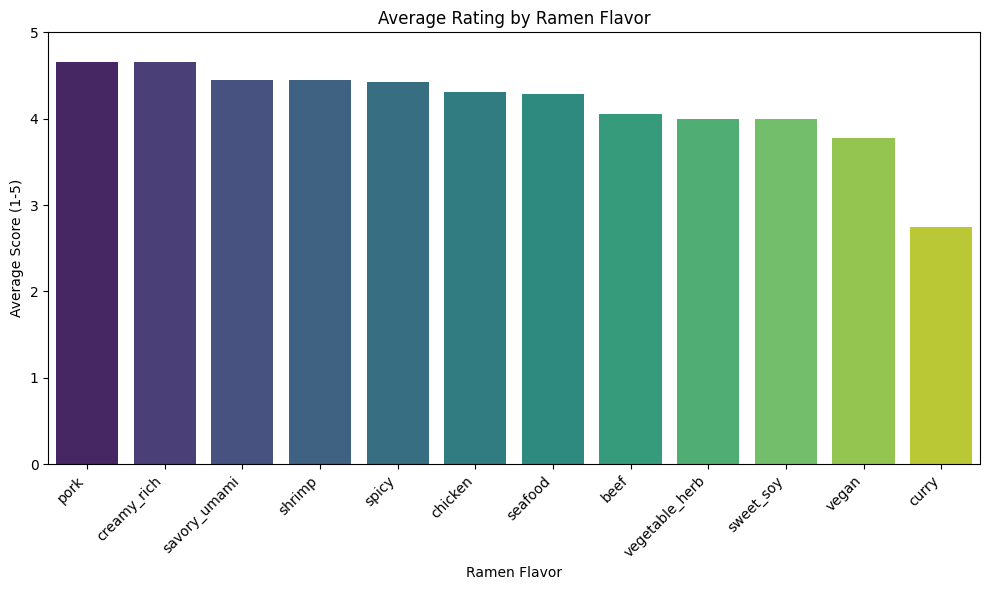

In [48]:
# To accurately get the 'Score' for each review with its new 'flavor',
# we need to ensure sentiment_df has the 'Score' column. It's currently in df_scores_aligned.
# Let's merge sentiment_df (which now has the updated 'flavor') with the original scores.
# The `sentiment_df_with_scores` variable from the kernel state includes 'Score' but its 'flavor' column might be outdated.
# So, I'll rebuild it from the updated sentiment_df.

# First, ensure sentiment_df has the latest flavors assigned by rerunning QQtM0adZzJLo
# Then, merge with df_scores_aligned to get the 'Score' column
sentiment_df_updated_with_scores = sentiment_df.merge(
    df.reset_index().rename(columns={'index': 'review_id'})[['review_id', 'Score']],
    on="review_id",
    how="left"
)

# Filter out reviews without an assigned flavor from this updated dataframe
flavor_scores = sentiment_df_updated_with_scores.dropna(subset=['flavor'])

# Calculate the average score for each flavor
average_flavor_scores = flavor_scores.groupby('flavor')['Score'].mean().reset_index()

# Create a bar chart for average scores by flavor
plt.figure(figsize=(10, 6))
sns.barplot(x='flavor', y='Score', data=average_flavor_scores.sort_values(by='Score', ascending=False), palette='viridis')
plt.title('Average Rating by Ramen Flavor')
plt.xlabel('Ramen Flavor')
plt.ylabel('Average Score (1-5)')
plt.ylim(0, 5) # Scores are typically 1-5
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Lastly checking the accuracy of the results comparing it to the original labels that where given by the amazon reviews. I also realize that peoples scales are completely different so someones, 1 star rating might be mild compared to a scathing 1 star review rating.

## Word Co-occurrence Network Analysis on Top-Rated Reviews

This section performs a word co-occurrence network analysis on reviews with the highest ratings to identify key word relationships within positive feedback.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Ensure NLTK resources are downloaded (already done earlier, but good practice)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt') # Needed for word_tokenize

# Filter for top-rated reviews (e.g., Score of 5)
top_rated_reviews_df = sentiment_df_updated_with_scores[sentiment_df_updated_with_scores['Score'] == 5].copy()

print(f"Number of top-rated reviews (Score = 5): {len(top_rated_reviews_df)}")
print(top_rated_reviews_df.head())

In [ ]:
stop_words_nltk = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_for_network(text):
    text = str(text).lower() # Ensure text is string and lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    tokens = nltk.word_tokenize(text) # Use NLTK's word_tokenize for better tokenization

    # Custom stopwords for network analysis - less aggressive than BERTopic
    # We want to keep words like 'ramen', 'noodle', 'flavor' to see their connections
    custom_stops = {'just', 'get', 'dont', 'got', 'br', 'com', 'amazon'}
    all_stops = stop_words_nltk.union(custom_stops)

    # Remove stopwords, lemmatize, and remove short words
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in all_stops and len(w) > 2]
    return tokens

# Apply this cleaning function to the top-rated reviews
top_rated_reviews_df['cleaned_tokens'] = top_rated_reviews_df['review_text'].apply(clean_text_for_network)

print(top_rated_reviews_df[['review_text', 'cleaned_tokens']].head())

In [ ]:
# Generate word co-occurrence pairs
window_size = 3 # Define co-occurrence window size
co_occurrences = Counter()

for tokens in top_rated_reviews_df['cleaned_tokens']:
    for i, word1 in enumerate(tokens):
        for j in range(i + 1, min(i + window_size, len(tokens))):
            word2 = tokens[j]
            if word1 != word2: # Avoid self-loops
                # Store pairs alphabetically to avoid (A,B) and (B,A)
                co_occurrences[tuple(sorted((word1, word2)))] += 1

# Create a graph
G = nx.Graph()

# Add edges based on co-occurrence frequency (e.g., only for occurrences > 5)
min_cooccurrence_freq = 5
for (word1, word2), freq in co_occurrences.items():
    if freq >= min_cooccurrence_freq:
        G.add_edge(word1, word2, weight=freq)

# Remove isolated nodes (words that don't co-occur frequently enough)
G.remove_nodes_from(list(nx.isolates(G)))

print(f"Number of nodes in the co-occurrence graph: {G.number_of_nodes()}")
print(f"Number of edges in the co-occurrence graph: {G.number_of_edges()}")

In [ ]:
# Visualize the network
plt.figure(figsize=(15, 12))

# Use spring layout for better visualization of clusters
pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=[v * 100 for v in dict(G.degree()).values()], node_color='skyblue', alpha=0.9)

# Draw edges
edges = nx.draw_networkx_edges(G, pos, width=[(G[u][v]['weight'] / max(co_occurrences.values())) * 5 for u, v in G.edges()], alpha=0.3, edge_color='gray')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title('Word Co-occurrence Network (Top-Rated Ramen Reviews)', size=20)
plt.axis('off')
plt.show()


In [ ]:
sentiment_df["predicted_label"] = sentiment_df["compound"].apply(
    lambda x: "pos" if x > 0 else "neg"
)

accuracy = (sentiment_df["label"] == sentiment_df["predicted_label"]).mean()
accuracy

